<a href="https://colab.research.google.com/github/kazutani2003/EU_M_Math/blob/main/Chap9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

9-2-1
データ全体の傾向から、自動でデータをいくつかのグループに分けるクラスタリングの代表的なアルゴリズム。
メリット：単純で、計算が速い、大規模なデータにも適用しやすい。
デメリット：最初のｋを人間が決める必要がある。外れ値に影響されやすい。球状以外の複雑な形状のグループ分けが苦手

9-2-2k-means法でクラスタリングする

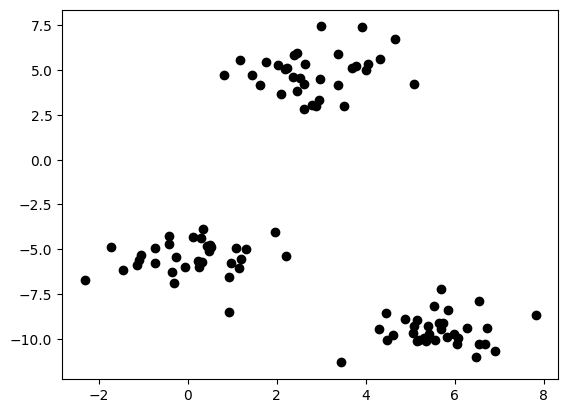

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt


x,_=make_blobs(random_state=10)
plt.scatter(x[:,0],x[:,1],color='black')

In [4]:
kmeans = KMeans(init='random',n_clusters=3)
kmeans.fit(x)
y_pred = kmeans.predict(x)

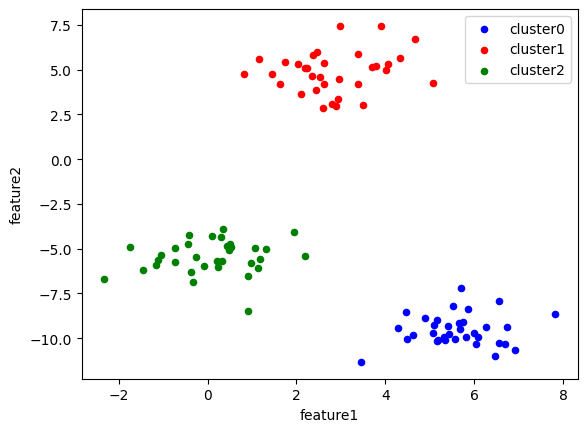

In [8]:
import pandas as pd
merge_data = pd.concat([pd.DataFrame(x[:,0]),pd.DataFrame(x[:,1]),pd.DataFrame(y_pred)],axis=1)

merge_data.columns = ['feature1','feature2','cluster']

ax = None
colors = ['blue','red','green']
for i, data in merge_data.groupby('cluster'):
  ax = data.plot.scatter(x='feature1',y='feature2',color=colors[i],label='cluster'+str(i),ax=ax)

練習問題9-1

/tmp/ipykernel_6442/2148137346.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


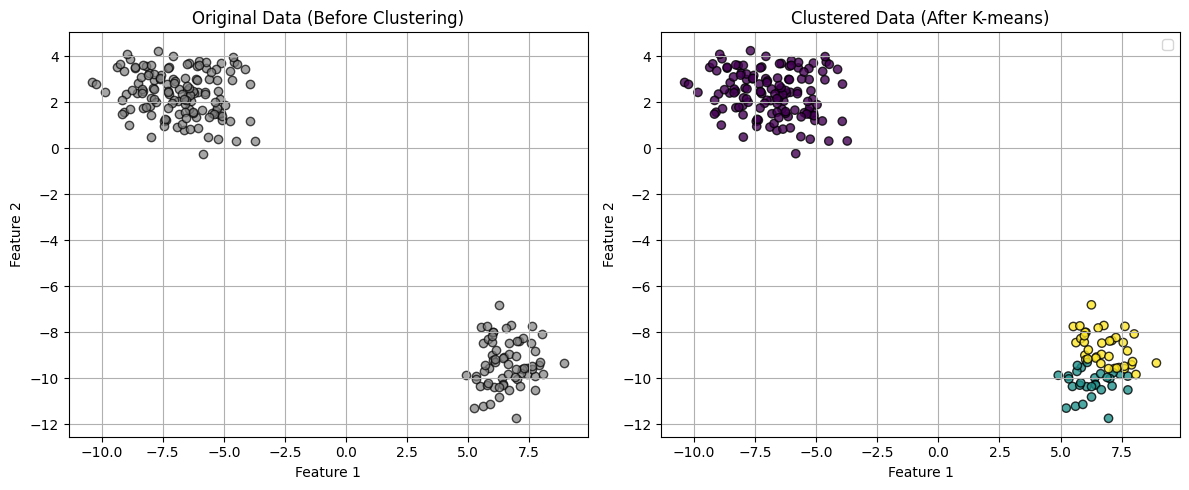

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=200, centers=3, n_features=2, random_state=52, cluster_std=1.0
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c="gray", edgecolors="k", alpha=0.7)
plt.title("Original Data (Before Clustering)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)

kmeans = KMeans(n_clusters=3, random_state=52, n_init="auto")
labels = kmeans.fit_predict(X)

plt.subplot(1, 2, 2)

scatter = plt.scatter(
    X[:, 0], X[:, 1], c=labels, cmap="viridis", edgecolors="k", alpha=0.8
)

plt.title("Clustered Data (After K-means)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.legend()

# グラフの表示
plt.tight_layout()
plt.show()

9-3-1

相関係数0.889:


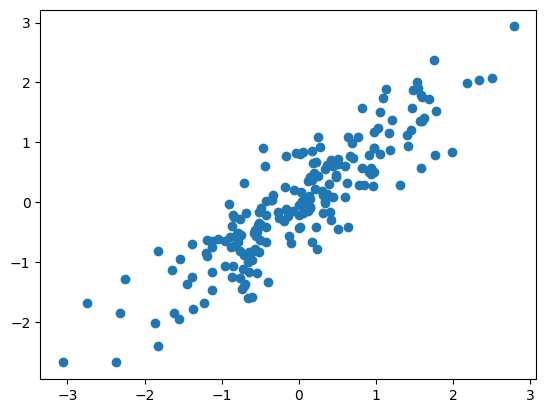

In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

sample = np.random.RandomState(1)
X = np.dot(sample.rand(2,2),sample.randn(2,200)).T

sc = StandardScaler()
X_std = sc.fit_transform(X)

print('相関係数{:.3f}:'.format(sp.stats.pearsonr(X_std[:,0],X_std[:,1])[0]))
plt.scatter(X_std[:,0],X_std[:,1])

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X_std)

PCA(n_components=2)

In [15]:
print(pca.components_)

[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]


In [16]:
print('各主成分の分散:{}'.format(pca.explained_variance_))


各主成分の分散:[1.89888438 0.11116588]


In [17]:
print('各主成分の分散割合:{}'.format(pca.explained_variance_ratio_))

各主成分の分散比:[0.94469498 0.05530502]


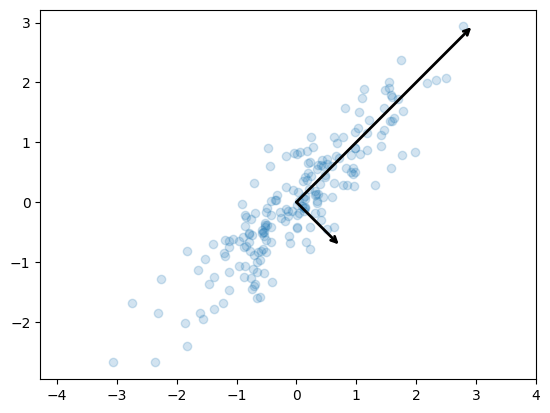

In [22]:
arrowprops=dict(arrowstyle='->',
                linewidth=2,
                shrinkA=0,shrinkB=0)

def draw_vector(v0,v1):
  plt.gca().annotate('',v1,v0,arrowprops=arrowprops)

plt.scatter(X_std[:,0],X_std[:,1],alpha=0.2)

for length,vector in zip(pca.explained_variance_,pca.components_):
  v=vector*3*np.sqrt(length)
  draw_vector(pca.mean_,pca.mean_+v)

plt.axis('equal');

9-3-2

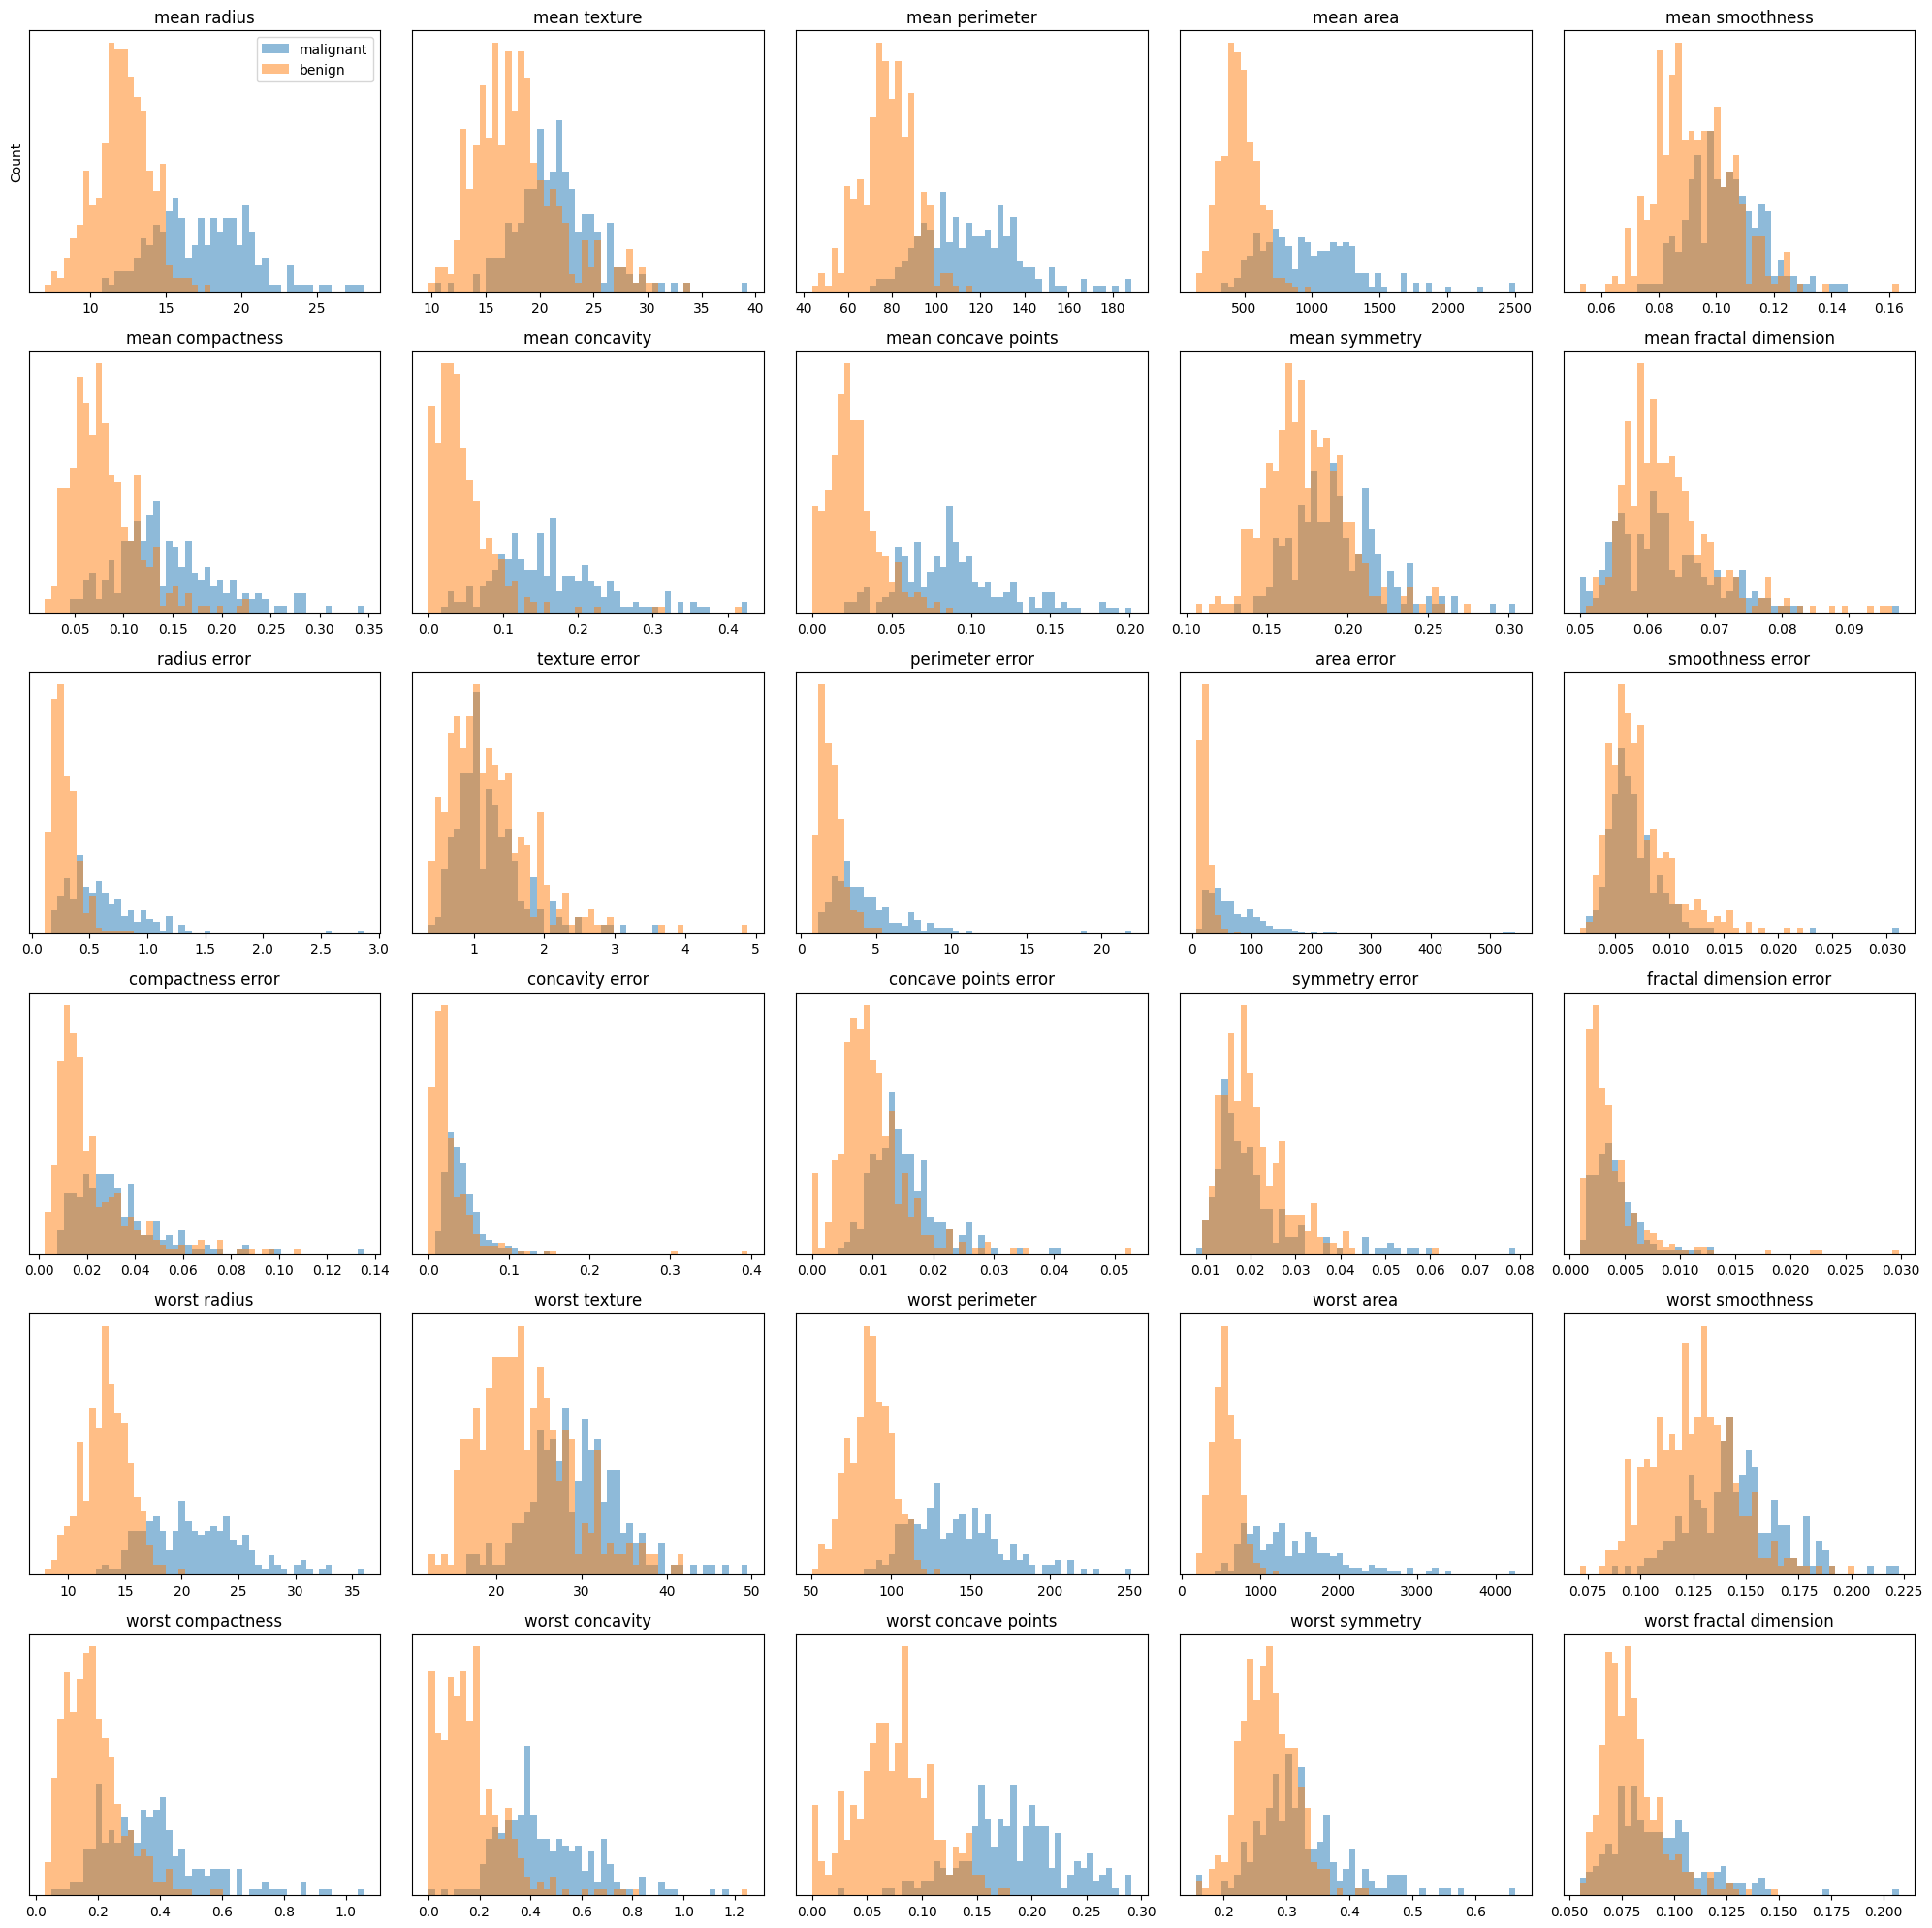

In [24]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

malignant = cancer.data[cancer.target==0]

benign = cancer.data[cancer.target==1]

fig, axes = plt.subplots(6,5,figsize=(20,20))
ax = axes.ravel()
for i in range(30):
  _,bins = np.histogram(cancer.data[:,i],bins=50)
  ax[i].hist(malignant[:,i],bins,alpha=.5)
  ax[i].hist(benign[:,i],bins,alpha=.5)
  ax[i].set_title(cancer.feature_names[i])
  ax[i].set_yticks(())

ax[0].set_ylabel('Count')
ax[0].legend(['malignant','benign'],loc='best')
fig.tight_layout()

In [26]:
sc = StandardScaler()
X_std = sc.fit_transform(cancer.data)

pca = PCA(n_components=2)
pca.fit(X_std)
X_pca = pca.transform(X_std)

print('X_pca shape:{}'.format(X_pca.shape))
print('Explained variance ratio:{}'.format(pca.explained_variance_ratio_))

X_pca shape:(569, 2)
Explained variance ratio:[0.44272026 0.18971182]


In [28]:
X_pca = pd.DataFrame(X_pca,columns=['pc1','pc2'])

X_pca = pd.concat([X_pca,pd.DataFrame(cancer.target,columns=['target'])],axis=1)

pca_malignant = X_pca[X_pca['target']==0]
pca_benign = X_pca[X_pca['target']==1]

<Axes: xlabel='pc1', ylabel='pc2'>

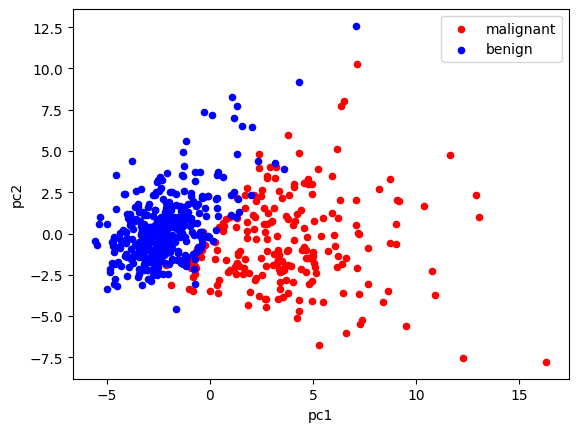

In [29]:
ax = pca_malignant.plot.scatter(x='pc1',y='pc2',color='red',label='malignant')
pca_benign.plot.scatter(x='pc1',y='pc2',color='blue',label='benign',ax=ax)